In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/clean/clean.csv")

df.head()

,order_id,product,category,quantity,price,city,date,total_price,year,month_number,month
0,ORD1001,Backpack,Accessories,1,1629.00,Hyderabad,2026-03-04,1629.00,2026,3,2026-03
1,ORD1002,Keyboard,Electronics,2,1570.94,Surat,2026-01-23,3141.88,2026,1,2026-01
2,ORD1003,Book,Books,4,407.86,Mumbai,2026-02-25,1631.44,2026,2,2026-02
3,ORD1004,Keyboard,Electronics,5,1530.61,Surat,2026-02-20,7653.05,2026,2,2026-02
4,ORD1005,Tablet,Electronics,5,27549.31,Jaipur,2026-05-31,137746.55,2026,5,2026-05


In [42]:
#Business KPI Summary

total_revenue = df["total_price"].sum()
total_orders = df["order_id"].nunique()
total_quantity = df["quantity"].sum()
aov = total_revenue / total_orders
avg_selling_price = df["price"].mean()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", round(aov, 2))
print("Average Selling Price:", round(avg_selling_price, 2))

Total Revenue: 27620651.09
Total Orders: 1000
Total Quantity Sold: 3035
Average Order Value: 27620.65
Average Selling Price: 8940.49


In [43]:
#Category revenue contribution

category_analysis = (
    df.groupby("category")
    .agg(
        revenue=("total_price", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

category_analysis["revenue_contribution_pct"] = (category_analysis["revenue"] / total_revenue * 100).round(2)

category_analysis = category_analysis.sort_values("revenue",ascending=False)

category_analysis

,category,revenue,quantity,orders,revenue_contribution_pct
2,Electronics,21606517.72,1017,328,78.23
4,Home Appliances,3141481.72,658,219,11.37
0,Accessories,1630446.50,482,161,5.90
3,Fashion,1152368.38,679,226,4.17
1,Books,89836.77,199,66,0.33


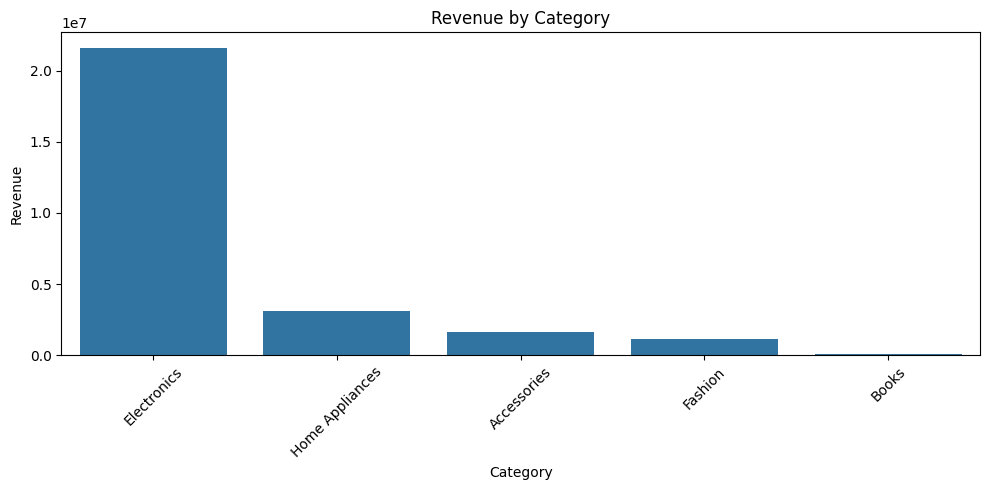

In [44]:
plt.figure(figsize=(10, 5))

sns.barplot(data=category_analysis,x="category",y="revenue")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
#Product Performance

product_analysis = (
    df.groupby("product")
    .agg(
        revenue=("total_price", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique"),
        average_price=("price", "mean")
    )
    .reset_index()
)

product_analysis["revenue_contribution_pct"] = (product_analysis["revenue"] / total_revenue * 100).round(2)

product_analysis = product_analysis.sort_values("revenue",ascending=False)

product_analysis.head(10)

,product,revenue,quantity,orders,average_price,revenue_contribution_pct
7,Laptop,11411335.18,207,65,55237.980769,41.31
12,Tablet,5933914.09,215,69,27555.183043,21.48
10,Smartphone,3535262.79,199,68,17853.839559,12.80
0,Air Fryer,1533421.53,239,78,6440.473077,5.55
13,Watch,1203724.83,241,79,5000.508608,4.36
3,Coffee Maker,812719.87,193,64,4218.196875,2.94
8,Mixer,795340.32,226,77,3534.571948,2.88
9,Shoes,515253.55,206,73,2507.791781,1.87
5,Jeans,428059.92,214,69,1993.427536,1.55
1,Backpack,426721.67,241,82,1780.637683,1.54


In [46]:
#Top 10 Products
top_10_products = product_analysis.head(10)

top_10_products

,product,revenue,quantity,orders,average_price,revenue_contribution_pct
7,Laptop,11411335.18,207,65,55237.980769,41.31
12,Tablet,5933914.09,215,69,27555.183043,21.48
10,Smartphone,3535262.79,199,68,17853.839559,12.80
0,Air Fryer,1533421.53,239,78,6440.473077,5.55
13,Watch,1203724.83,241,79,5000.508608,4.36
3,Coffee Maker,812719.87,193,64,4218.196875,2.94
8,Mixer,795340.32,226,77,3534.571948,2.88
9,Shoes,515253.55,206,73,2507.791781,1.87
5,Jeans,428059.92,214,69,1993.427536,1.55
1,Backpack,426721.67,241,82,1780.637683,1.54


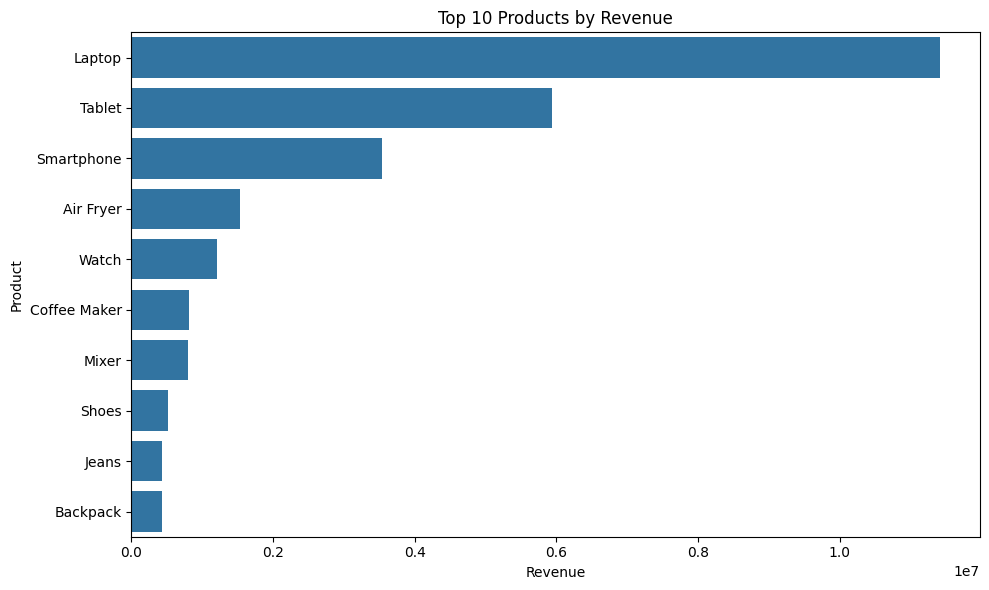

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(data=top_10_products,y="product",x="revenue")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [48]:
#High Volume but Low-revenue products
revenue_median = product_analysis["revenue"].median()
quantity_median = product_analysis["quantity"].median()

high_volume_low_revenue = product_analysis[(product_analysis["quantity"] > quantity_median) &(product_analysis["revenue"] < revenue_median)]

high_volume_low_revenue

,product,revenue,quantity,orders,average_price,revenue_contribution_pct
1,Backpack,426721.67,241,82,1780.637683,1.54
6,Keyboard,329956.17,218,69,1510.957971,1.19
11,T-Shirt,209054.91,259,84,809.953452,0.76


In [49]:
#City Performance
city_analysis = (
    df.groupby("city")
    .agg(
        revenue=("total_price", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .reset_index()
)

city_analysis["aov"] = (city_analysis["revenue"] /city_analysis["orders"]).round(2)

city_analysis["revenue_contribution_pct"] = (city_analysis["revenue"] /total_revenue * 100).round(2)

city_analysis = city_analysis.sort_values("revenue",ascending=False)

city_analysis


,city,revenue,orders,quantity,aov,revenue_contribution_pct
8,Pune,3262077.43,102,307,31981.15,11.81
7,Mumbai,3213056.46,126,378,25500.45,11.63
5,Jaipur,3161091.50,105,312,30105.63,11.44
1,Bangalore,3148292.69,88,270,35776.05,11.40
6,Kolkata,2971339.46,87,267,34153.33,10.76
9,Surat,2798244.03,105,334,26649.94,10.13
3,Delhi,2660336.42,94,281,28301.45,9.63
2,Chennai,2359385.36,98,308,24075.36,8.54
0,Ahmedabad,2127277.96,99,302,21487.66,7.70
4,Hyderabad,1919549.78,96,276,19995.31,6.95


In [50]:
# Monthly Business Performance
monthly_analysis = (
    df.groupby("month")
    .agg(
        revenue=("total_price", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .reset_index()
    .sort_values("month")
)

monthly_analysis

,month,revenue,orders,quantity
0,2026-01,5205216.14,170,521
1,2026-02,4418598.64,151,462
2,2026-03,4668486.25,181,532
3,2026-04,4655427.19,164,511
4,2026-05,4860089.35,184,522
5,2026-06,3812833.52,150,487


In [51]:
#Month-over-Month Growth

monthly_analysis["mom_growth_pct"] = (monthly_analysis["revenue"].pct_change() * 100).round(2)

monthly_analysis

,month,revenue,orders,quantity,mom_growth_pct
0,2026-01,5205216.14,170,521,NaN
1,2026-02,4418598.64,151,462,-15.11
2,2026-03,4668486.25,181,532,5.66
3,2026-04,4655427.19,164,511,-0.28
4,2026-05,4860089.35,184,522,4.40
5,2026-06,3812833.52,150,487,-21.55


In [52]:
highest_growth_month = monthly_analysis.loc[monthly_analysis["mom_growth_pct"].idxmax()]

lowest_growth_month = monthly_analysis.loc[monthly_analysis["mom_growth_pct"].idxmin()]

print("Highest growth:")
print(highest_growth_month)

print("\nLowest growth:")
print(lowest_growth_month)

Highest growth:
month                2026-03
revenue           4668486.25
orders                   181
quantity                 532
mom_growth_pct          5.66
Name: 2, dtype: object

Lowest growth:
month                2026-06
revenue           3812833.52
orders                   150
quantity                 487
mom_growth_pct        -21.55
Name: 5, dtype: object


In [53]:
monthly_analysis["cumulative_revenue"] = (monthly_analysis["revenue"].cumsum())

monthly_analysis

,month,revenue,orders,quantity,mom_growth_pct,cumulative_revenue
0,2026-01,5205216.14,170,521,NaN,5205216.14
1,2026-02,4418598.64,151,462,-15.11,9623814.78
2,2026-03,4668486.25,181,532,5.66,14292301.03
3,2026-04,4655427.19,164,511,-0.28,18947728.22
4,2026-05,4860089.35,184,522,4.40,23807817.57
5,2026-06,3812833.52,150,487,-21.55,27620651.09


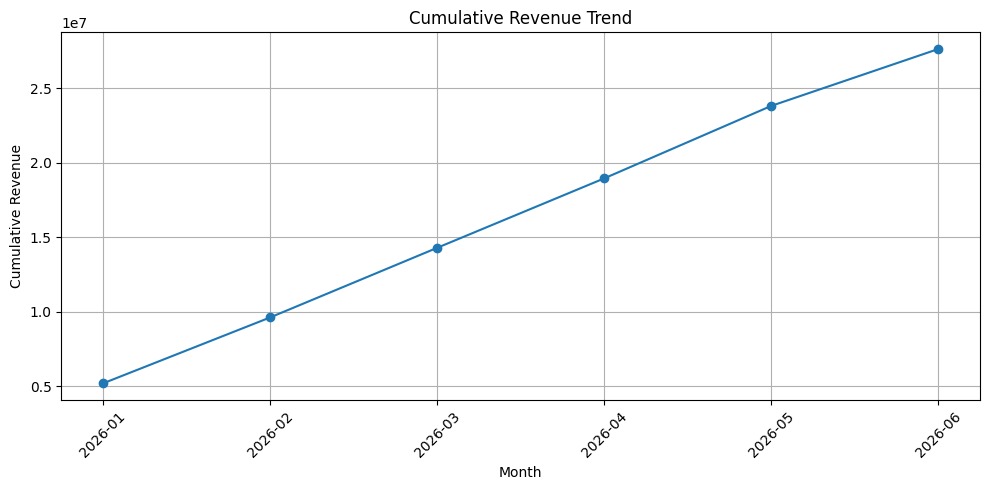

In [54]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_analysis["month"],
    monthly_analysis["cumulative_revenue"],
    marker="o"
)

plt.title("Cumulative Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Cumulative Revenue")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [55]:
#Top Products Within Each Category

category_product = (df.groupby(["category", "product"])["total_price"].sum().reset_index())

category_product["rank"] = (
    category_product
    .groupby("category")["total_price"].rank(method="dense",ascending=False))

top_products_category = category_product[category_product["rank"] <= 3
].sort_values(["category", "rank"])

top_products_category

,category,product,total_price,rank
1,Accessories,Watch,1203724.83,1.0
0,Accessories,Backpack,426721.67,2.0
2,Books,Book,89836.77,1.0
5,Electronics,Laptop,11411335.18,1.0
7,Electronics,Tablet,5933914.09,2.0
6,Electronics,Smartphone,3535262.79,3.0
9,Fashion,Shoes,515253.55,1.0
8,Fashion,Jeans,428059.92,2.0
10,Fashion,T-Shirt,209054.91,3.0
11,Home Appliances,Air Fryer,1533421.53,1.0


In [56]:
top_5_revenue = product_analysis.head(5)["revenue"].sum()

top_5_contribution = (top_5_revenue / total_revenue * 100)

print("Top 5 products revenue contribution:",round(top_5_contribution, 2),"%")

Top 5 products revenue contribution: 85.51 %


In [57]:
product_monthly = (df.groupby(["month", "product"])["total_price"].sum().reset_index())

first_month = product_monthly["month"].min()
last_month = product_monthly["month"].max()

first_month_revenue = product_monthly[product_monthly["month"] == first_month
].set_index("product")["total_price"]

last_month_revenue = product_monthly[product_monthly["month"] == last_month
].set_index("product")["total_price"]

In [58]:
product_change = pd.DataFrame({
    "first_month_revenue": first_month_revenue,
    "last_month_revenue": last_month_revenue
}).fillna(0)

product_change["revenue_change_pct"] = np.where(
    product_change["first_month_revenue"] > 0,
    (
    (product_change["last_month_revenue"] -product_change["first_month_revenue"])
        / product_change["first_month_revenue"]
    ) * 100,
    np.nan
)

product_change.sort_values(
    "revenue_change_pct"
).head(10)

,first_month_revenue,last_month_revenue,revenue_change_pct
product,,,
Jeans,88338.21,32815.24,-62.852723
Laptop,2439266.12,1358576.55,-44.303881
Mixer,130635.98,88883.02,-31.961302
Tablet,1129987.59,842323.24,-25.457302
Smartphone,630916.34,475630.20,-24.612794
T-Shirt,37271.82,31262.55,-16.122824
Book,20771.93,19904.68,-4.175106
Keyboard,61213.92,58888.71,-3.798499
Backpack,85832.67,92533.08,7.806363


Here's the filled-in business findings summary:

Business Findings
Revenue
- Total revenue: ₹2,76,20,651 (₹27.62M)
- Total orders: 1,000
- Total quantity sold: 3,035 units
- Average order value (AOV): ₹27,620.65
- Average selling price: ₹8,940.49
- Highest-revenue category: Electronics — ₹2,16,06,517.72 (78.23% of total revenue), despite only being 328 of 1,000 orders


Products
- Top product by revenue: Laptop — ₹1,14,11,335.18 (41.31% of total revenue, avg price ₹55,238)
- Top 5 product revenue contribution: 85.51% (Laptop, Tablet, Smartphone, Air Fryer, Watch)
- High-volume/low-revenue products: Backpack, Keyboard, T-Shirt — each sold 218–259 units (among the highest quantities in the dataset) but contribute under 1.6% of revenue each due to low unit price (₹800–₹1,780 avg)

Geography
- Highest-revenue city: Pune — ₹32,62,077.43 (11.81%), despite Mumbai having more orders (126 vs. 102)
- Highest-AOV city: Bangalore — ₹35,776 average order value (fewer, higher-value orders), followed by Kolkata (₹34,153) and Pune (₹31,981)

Trends
- Highest-growth month: March 2026 (+5.66% MoM, ₹46.68L)
- Lowest-growth month: June 2026 (-21.55% MoM, dropping to ₹38.13L — the lowest month in the dataset)
- Overall revenue trend: Choppy/non-linear — revenue dipped in Feb (-15.11%), recovered through Mar–May, then fell sharply in June. Cumulative revenue still grew steadily to ₹2.76 crore, but the June drop breaks the recovery pattern and warrants investigation (seasonality, stock-outs, or incomplete month data)
- Notable product-level decline: Jeans (-62.9%), Laptop (-44.3%), Mixer (-32.0%), Tablet (-25.5%), and Smartphone (-24.6%) all saw revenue fall sharply from first to last month — concerning since Laptop and Tablet are the top 2 revenue drivers. Air Fryer (+10.8%) and Backpack (+7.8%) were the only products to grow.

Business Opportunities

- Category concentration risk: 78% of revenue rides on Electronics, and within that, Laptop alone is 41% of total revenue — a single-category/single-product dependency that's risky if demand shifts or a competitor undercuts pricing. Diversifying marketing push toward Home Appliances/Fashion could reduce this concentration.
- Reverse the Laptop/Tablet decline: Since these two products are down 44% and 25% respectively from first to last month while driving 63% of total revenue combined, root-causing that drop (pricing, inventory, competition, seasonality) should be the top priority — a continued slide would hit total revenue hard.
- Geographic expansion: Hyderabad and Ahmedabad lag the top cities by ~₹1.1–1.3M despite similar order counts — worth investigating whether it's a marketing/reach gap or genuine lower demand, since closing that gap even partially adds meaningful revenue.
- Bundle low-ticket, high-volume items: Backpack, Keyboard, and T-Shirt move high quantity but contribute minimal revenue — bundling them with high-margin Electronics (e.g., "Laptop + Backpack" combo) could lift AOV without new customer acquisition cost.

# Business Findings & Recommendations

## 1. Revenue Performance

- Total revenue reached **₹2,76,20,651 (₹27.62M)** across **1,000 orders** and **3,035 units sold**.
- Average Order Value (AOV) was **₹27,620.65**, while the average selling price was **₹8,940.49**.
- Electronics generated **₹2,16,06,517.72**, representing **78.23% of total revenue**, despite accounting for only **328 of 1,000 orders**.
- This indicates that revenue performance is strongly influenced by high-value Electronics purchases rather than order volume alone.

## 2. Product Performance

- **Laptop** was the highest-revenue product, generating **₹1,14,11,335.18**, equivalent to **41.31% of total revenue**, with an average selling price of approximately **₹55,238**.
- The top five products — Laptop, Tablet, Smartphone, Air Fryer, and Watch — contributed approximately **85.51% of total revenue**.
- Backpack, Keyboard, and T-Shirt recorded relatively high unit volumes but contributed less than **1.6% of revenue each**, reflecting their lower selling prices.
- This shows a significant difference between **sales volume and revenue contribution** across products.

## 3. Geographic Performance

- **Pune** generated the highest city-level revenue at approximately **₹32.62 lakh**, contributing **11.81% of total revenue**.
- Mumbai recorded more orders than Pune (**126 vs. 102**), but Pune generated higher revenue, indicating stronger revenue per order.
- **Bangalore** recorded the highest AOV at approximately **₹35,776**, followed by Kolkata (~₹34,153) and Pune (~₹31,981).
- This indicates that some cities generate stronger revenue through higher-value orders rather than simply higher order volumes.

## 4. Monthly Performance

- Revenue performance was non-linear throughout the six-month period.
- Revenue declined by **15.11% in February** before recovering during March–May.
- **March recorded the highest MoM growth at +5.66%**.
- **June recorded the lowest MoM growth at -21.55%**, with revenue falling to approximately **₹38.13 lakh**, the lowest monthly revenue in the dataset.
- The June decline should be investigated for possible factors such as seasonality, inventory availability, pricing changes, competitive pressure, or incomplete-period data.

## 5. Product-Level Trend Risk

Several products experienced substantial revenue declines between the first and last months:

| Product | Revenue Change |
|---|---:|
| Jeans | -62.9% |
| Laptop | -44.3% |
| Mixer | -32.0% |
| Tablet | -25.5% |
| Smartphone | -24.6% |

- The decline in Laptop and Tablet is particularly important because these products are major contributors to total revenue.
- Air Fryer (+10.8%) and Backpack (+7.8%) were among the products showing positive growth.
- Continued declines in high-revenue products could have a significant impact on overall revenue performance.

## 6. Business Opportunities

### A. Reduce Revenue Concentration Risk

Electronics contributes **78.23% of total revenue**, while Laptop alone contributes **41.31%**.

This creates a significant dependency on a single category and product. Management should evaluate opportunities to increase the contribution of Home Appliances, Fashion, Accessories, and other categories through targeted promotions and product strategies.

### B. Investigate Laptop and Tablet Decline

Laptop and Tablet are major revenue drivers but experienced substantial declines between the first and last months.

Potential factors to investigate include:

- Pricing changes
- Inventory availability
- Competitive pricing
- Product demand
- Seasonal effects
- Promotional activity

### C. Investigate Lower-Performing Cities

Hyderabad and Ahmedabad generate lower revenue than the leading cities despite having comparable order volumes.

Further analysis should examine whether the gap is related to:

- Lower Average Order Value
- Product mix
- Customer demand
- Marketing reach
- Product availability

### D. Bundle High-Volume, Low-Revenue Products

Backpack, Keyboard, and T-Shirt generate relatively high unit volumes but low revenue contribution.

These products could be evaluated for **cross-selling and bundling opportunities**, such as pairing complementary lower-priced products with Electronics purchases.

The objective would be to increase Average Order Value and improve the revenue contribution of lower-ticket products.
